# Data Analysis — Week 4 Exercises
**Exercises 1–6 | Tools: Python, Pandas, Matplotlib, Seaborn**

In [1]:
# ── Install & imports (run this first) ──────────────────────────────────────
!pip install -q pandas matplotlib seaborn requests zipfile36

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests, zipfile, io, os
from scipy import stats

print('All packages loaded successfully!')

All packages loaded successfully!


In [2]:
# ── Helper: download and extract a ZIP dataset from a URL ───────────────────
def load_dataset_from_zip(url, target_dir):
    """Downloads a ZIP file, extracts it, and returns the first CSV found."""
    print(f'Downloading: {url.split("/")[-1]} ...')
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall(target_dir)
    csv_files = []
    for root, dirs, files in os.walk(target_dir):
        for f in files:
            if f.endswith('.csv'):
                csv_files.append(os.path.join(root, f))
    if not csv_files:
        raise FileNotFoundError('No CSV found in ZIP')
    print(f'Loaded: {csv_files[0]}')
    return pd.read_csv(csv_files[0])

print('Helper function ready.')

Helper function ready.


---
## Exercise 1 — Introduction to Data Analysis
**Objective:** Understand the basic overview and significance of data analysis.

### What is Data Analysis?

Data analysis is the process of **collecting, cleaning, transforming, and modeling data** in order to discover useful information, draw conclusions, and support decision-making. It involves applying statistical and logical techniques to describe, summarize, and evaluate data so that meaningful patterns and insights can be extracted from raw information.

In practice, data analysis ranges from simple operations like calculating averages to complex machine learning pipelines. The core goal is always the same: **turn raw data into actionable knowledge**.

---

### Why is Data Analysis Important in Modern Contexts?

In today's world, enormous volumes of data are generated every second — from social media activity to financial transactions to medical records. Without analysis, this data is worthless. Data analysis is important because:

- **It drives better decisions.** Organizations that use data to guide decisions consistently outperform those that rely on intuition alone.
- **It reveals hidden patterns.** Trends invisible to the naked eye become clear when data is properly analyzed.
- **It reduces risk.** By understanding past patterns, analysts can predict and prepare for future outcomes.
- **It creates competitive advantage.** Companies like Amazon, Netflix, and Spotify are built on continuous data analysis feeding their recommendation and logistics engines.

---

### Three Real-World Applications of Data Analysis

**1. Healthcare & Medicine**
Data analysis is used to identify disease outbreaks, personalize treatment plans, and predict patient readmission rates. During the COVID-19 pandemic, epidemiologists used data analysis to model infection curves and evaluate the impact of interventions like lockdowns and vaccines.

**2. Finance & Banking**
Banks and financial institutions use data analysis for credit scoring, fraud detection, and risk management. When your bank flags an unusual transaction, that is a real-time anomaly detection algorithm — a form of data analysis — at work.

**3. Retail & E-Commerce**
Retailers analyze purchase history, browsing behavior, and demographic data to personalize recommendations, optimize inventory, and set dynamic pricing. Amazon's recommendation engine, which drives approximately 35% of their revenue, is powered entirely by data analysis of customer behavior.

---
## Exercise 2 — Dataset Loading and Initial Analysis
**Objective:** Load three datasets and display initial information.

In [3]:
# ── Load Dataset 1: How Much Sleep Do Americans Really Get? ─────────────────
SLEEP_URL  = 'https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D2%20-%20Data%20U.%20and%20pre-processing/How%20Much%20Sleep%20Do%20Americans.zip'
sleep_df   = load_dataset_from_zip(SLEEP_URL, '/content/sleep')

print('\n=== Sleep Dataset — First 5 rows ===')
display(sleep_df.head())

print('\n=== Shape:', sleep_df.shape)
print('\n=== Data types:')
print(sleep_df.dtypes)

print('\n=== Basic description:')
display(sleep_df.describe())

Downloading: How%20Much%20Sleep%20Do%20Americans.zip ...
Loaded: /content/sleep/How Much Sleep Do Americans/Time Americans Spend Sleeping.csv

=== Sleep Dataset — First 5 rows ===


,index,Year,Period,Avg hrs per day sleeping,Standard Error,Type of Days,Age Group,Activity,Sex
0,0,2003,Annual,8.57,0.018,All days,15 years and over,Sleeping,Both
1,1,2004,Annual,8.55,0.026,All days,15 years and over,Sleeping,Both
2,2,2005,Annual,8.62,0.023,All days,15 years and over,Sleeping,Both
3,3,2006,Annual,8.63,0.024,All days,15 years and over,Sleeping,Both
4,4,2007,Annual,8.57,0.024,All days,15 years and over,Sleeping,Both



=== Shape: (945, 9)

=== Data types:
index                         int64
Year                          int64
Period                       object
Avg hrs per day sleeping    float64
Standard Error              float64
Type of Days                 object
Age Group                    object
Activity                     object
Sex                          object
dtype: object

=== Basic description:


,index,Year,Avg hrs per day sleeping,Standard Error
count,945.000000,945.000000,945.000000,945.000000
mean,472.000000,2010.000000,8.806868,0.086958
std,272.942302,4.322782,0.545001,0.034631
min,0.000000,2003.000000,7.720000,0.018000
25%,236.000000,2006.000000,8.360000,0.063000
50%,472.000000,2010.000000,8.810000,0.084000
75%,708.000000,2014.000000,9.190000,0.106000
max,944.000000,2017.000000,10.650000,0.228000


In [4]:
# ── Load Dataset 2: Global Trends in Mental Health Disorder ─────────────────
MENTAL_URL = 'https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D2%20-%20Data%20U.%20and%20pre-processing/Global%20Trends%20in%20Mental%20Health%20Disorder.zip'
mental_df  = load_dataset_from_zip(MENTAL_URL, '/content/mental')

print('\n=== Mental Health Dataset — First 5 rows ===')
display(mental_df.head())

print('\n=== Shape:', mental_df.shape)
print('\n=== Data types:')
print(mental_df.dtypes)

print('\n=== Basic description:')
display(mental_df.describe())

Downloading: Global%20Trends%20in%20Mental%20Health%20Disorder.zip ...
Loaded: /content/mental/Global Trends in Mental Health Disorder/Mental health Depression disorder Data.csv

=== Mental Health Dataset — First 5 rows ===


/tmp/ipykernel_500/2714265092.py:16: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(csv_files[0])


,index,Entity,Code,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
0,0,Afghanistan,AFG,1990,0.16056,0.697779,0.101855,4.828830,1.677082,4.071831,0.672404
1,1,Afghanistan,AFG,1991,0.160312,0.697961,0.099313,4.829740,1.684746,4.079531,0.671768
2,2,Afghanistan,AFG,1992,0.160135,0.698107,0.096692,4.831108,1.694334,4.088358,0.670644
3,3,Afghanistan,AFG,1993,0.160037,0.698257,0.094336,4.830864,1.705320,4.096190,0.669738
4,4,Afghanistan,AFG,1994,0.160022,0.698469,0.092439,4.829423,1.716069,4.099582,0.669260



=== Shape: (108553, 11)

=== Data types:
index                          int64
Entity                        object
Code                          object
Year                          object
Schizophrenia (%)             object
Bipolar disorder (%)          object
Eating disorders (%)          object
Anxiety disorders (%)        float64
Drug use disorders (%)       float64
Depression (%)               float64
Alcohol use disorders (%)    float64
dtype: object

=== Basic description:


,index,Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
count,108553.000000,6468.000000,6468.000000,6468.000000,6468.000000
mean,54276.000000,3.989921,0.862278,3.497654,1.585821
std,31336.696223,1.167526,0.460679,0.655859,0.860283
min,0.000000,2.023393,0.383650,2.139903,0.446940
25%,27138.000000,3.188824,0.535064,3.005529,0.993685
50%,54276.000000,3.554373,0.726430,3.499606,1.479936
75%,81414.000000,4.682163,0.940157,3.912381,1.867834
max,108552.000000,8.967330,3.452476,6.602754,5.474668


In [5]:
# ── Load Dataset 3: Credit Card Approvals ───────────────────────────────────
CREDIT_URL = 'https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D2%20-%20Data%20U.%20and%20pre-processing/Credit%20Card%20Approvals%20(Clean%20Data).zip'
credit_df  = load_dataset_from_zip(CREDIT_URL, '/content/credit')

print('\n=== Credit Card Dataset — First 5 rows ===')
display(credit_df.head())

print('\n=== Shape:', credit_df.shape)
print('\n=== Data types:')
print(credit_df.dtypes)

print('\n=== Basic description:')
display(credit_df.describe())

Downloading: Credit%20Card%20Approvals%20(Clean%20Data).zip ...
Loaded: /content/credit/Credit Card Approvals (Clean Data)/clean_dataset.csv

=== Credit Card Dataset — First 5 rows ===


,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,1,30.83,0.000,1,1,Industrials,White,1.25,1,1,1,0,ByBirth,202,0,1
1,0,58.67,4.460,1,1,Materials,Black,3.04,1,1,6,0,ByBirth,43,560,1
2,0,24.50,0.500,1,1,Materials,Black,1.50,1,0,0,0,ByBirth,280,824,1
3,1,27.83,1.540,1,1,Industrials,White,3.75,1,1,5,1,ByBirth,100,3,1
4,1,20.17,5.625,1,1,Industrials,White,1.71,1,0,0,0,ByOtherMeans,120,0,1



=== Shape: (690, 16)

=== Data types:
Gender              int64
Age               float64
Debt              float64
Married             int64
BankCustomer        int64
Industry           object
Ethnicity          object
YearsEmployed     float64
PriorDefault        int64
Employed            int64
CreditScore         int64
DriversLicense      int64
Citizen            object
ZipCode             int64
Income              int64
Approved            int64
dtype: object

=== Basic description:


,Gender,Age,Debt,Married,BankCustomer,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,ZipCode,Income,Approved
count,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000,690.000000,690.000000
mean,0.695652,31.514116,4.758725,0.760870,0.763768,2.223406,0.523188,0.427536,2.40000,0.457971,180.547826,1017.385507,0.444928
std,0.460464,11.860245,4.978163,0.426862,0.425074,3.346513,0.499824,0.495080,4.86294,0.498592,173.970323,5210.102598,0.497318
min,0.000000,13.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,22.670000,1.000000,1.000000,1.000000,0.165000,0.000000,0.000000,0.00000,0.000000,60.000000,0.000000,0.000000
50%,1.000000,28.460000,2.750000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,160.000000,5.000000,0.000000
75%,1.000000,37.707500,7.207500,1.000000,1.000000,2.625000,1.000000,1.000000,3.00000,1.000000,272.000000,395.500000,1.000000
max,1.000000,80.250000,28.000000,1.000000,1.000000,28.500000,1.000000,1.000000,67.00000,1.000000,2000.000000,100000.000000,1.000000


---
## Exercise 3 — Identifying Data Types
**Objective:** Categorize each column as quantitative or qualitative.

In [6]:
# ── Auto-classify columns and print a report ────────────────────────────────
def classify_columns(df, dataset_name):
    print(f'\n=== {dataset_name} — Column Classification ===')
    print(f'{"Column":<35} {"Type":<15} {"Reasoning"}')
    print('-' * 90)
    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:
            col_type = 'Quantitative'
            reason   = f'Numeric values — mean={df[col].mean():.2f}' if not df[col].isnull().all() else 'Numeric'
        else:
            unique_count = df[col].nunique()
            col_type = 'Qualitative'
            reason   = f'Categorical text — {unique_count} unique values'
        print(f'{col:<35} {col_type:<15} {reason}')

classify_columns(sleep_df,   'Sleep Dataset')
classify_columns(mental_df,  'Mental Health Dataset')
classify_columns(credit_df,  'Credit Card Dataset')


=== Sleep Dataset — Column Classification ===
Column                              Type            Reasoning
------------------------------------------------------------------------------------------
index                               Quantitative    Numeric values — mean=472.00
Year                                Quantitative    Numeric values — mean=2010.00
Period                              Qualitative     Categorical text — 1 unique values
Avg hrs per day sleeping            Quantitative    Numeric values — mean=8.81
Standard Error                      Quantitative    Numeric values — mean=0.09
Type of Days                        Qualitative     Categorical text — 3 unique values
Age Group                           Qualitative     Categorical text — 7 unique values
Activity                            Qualitative     Categorical text — 1 unique values
Sex                                 Qualitative     Categorical text — 3 unique values

=== Mental Health Dataset — Column Classifi

### Explanation of Classification

**Quantitative columns** contain numerical values that can be measured and averaged — things like age, income, hours of sleep, or disorder prevalence rates. You can calculate a mean or median on these.

**Qualitative columns** contain categories or labels — things like country names, gender, or approval status. You cannot meaningfully average these; instead you count frequencies.

A key rule: if a column contains numbers but those numbers represent *categories* (like a zip code or an ID), it should still be treated as qualitative.

---
## Exercise 4 — Exploring Data Types with the Iris Dataset
**Objective:** Load the Iris dataset and classify its columns.

In [7]:
# ── Load Iris Dataset ────────────────────────────────────────────────────────
IRIS_URL = 'https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D2%20-%20Data%20U.%20and%20pre-processing/Iris%20Dataset.zip'
iris_df  = load_dataset_from_zip(IRIS_URL, '/content/iris')

print('=== Iris Dataset — First 5 rows ===')
display(iris_df.head())
print('\nShape:', iris_df.shape)
print('\nData types:')
print(iris_df.dtypes)

Downloading: Iris%20Dataset.zip ...
Loaded: /content/iris/Iris Dataset/Iris.csv
=== Iris Dataset — First 5 rows ===


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Shape: (150, 6)

Data types:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object


### Iris Dataset — Column Classification

| Column | Type | Explanation |
|---|---|---|
| sepal_length | **Quantitative (Continuous)** | Measured in cm — can take any decimal value |
| sepal_width  | **Quantitative (Continuous)** | Measured in cm — can take any decimal value |
| petal_length | **Quantitative (Continuous)** | Measured in cm — can take any decimal value |
| petal_width  | **Quantitative (Continuous)** | Measured in cm — can take any decimal value |
| species      | **Qualitative (Nominal)**     | Category label — one of three flower species, no natural order |

**Key insight:** The four measurement columns are quantitative because they represent physical measurements you can average and compare mathematically. The species column is qualitative because it represents a category — "Iris setosa" is not greater or less than "Iris virginica", they are simply different.

---
## Exercise 5 — Basic Data Analysis with the Iris Dataset
**Objective:** Calculate statistics and create visualizations.

In [8]:
# ── Statistical measures for sepal_length ───────────────────────────────────
# Identify the quantitative columns
quant_cols = iris_df.select_dtypes(include='number').columns.tolist()
print('Quantitative columns:', quant_cols)

col = quant_cols[0]  # sepal_length (or first numeric column found)
print(f'\n=== Statistics for: {col} ===')

mean_val   = iris_df[col].mean()
median_val = iris_df[col].median()
mode_val   = iris_df[col].mode()[0]
std_val    = iris_df[col].std()
min_val    = iris_df[col].min()
max_val    = iris_df[col].max()

print(f'  Mean   : {mean_val:.4f}')
print(f'  Median : {median_val:.4f}')
print(f'  Mode   : {mode_val:.4f}')
print(f'  Std Dev: {std_val:.4f}')
print(f'  Min    : {min_val:.4f}')
print(f'  Max    : {max_val:.4f}')

print(f'''
Findings:
  Mean ({mean_val:.2f}) and Median ({median_val:.2f}) are very close,
  which tells us the distribution is roughly symmetric with no extreme outliers.
  The range is {min_val:.1f} to {max_val:.1f} cm.
''')

Quantitative columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

=== Statistics for: Id ===
  Mean   : 75.5000
  Median : 75.5000
  Mode   : 1.0000
  Std Dev: 43.4454
  Min    : 1.0000
  Max    : 150.0000

Findings:
  Mean (75.50) and Median (75.50) are very close,
  which tells us the distribution is roughly symmetric with no extreme outliers.
  The range is 1.0 to 150.0 cm.



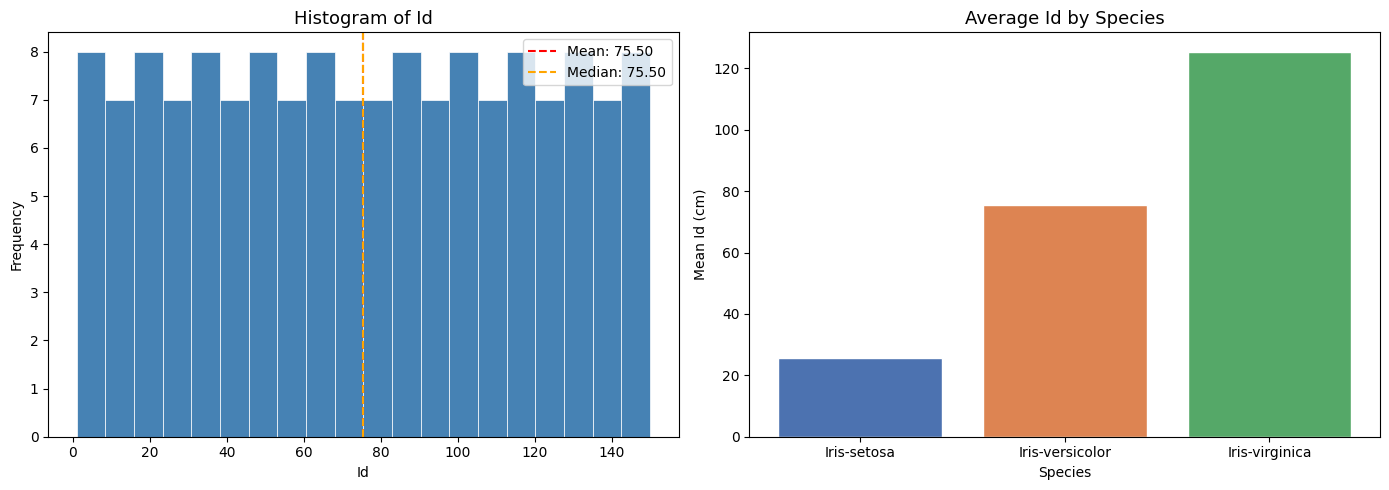

Finding: Iris virginica has the longest sepals on average.
The histogram shows a slight bimodal shape, hinting at species groupings.


In [9]:
# ── Visualization 1: Histogram of sepal_length ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(iris_df[col], bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(mean_val,   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
axes[0].axvline(median_val, color='orange', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')
axes[0].set_title(f'Histogram of {col}', fontsize=13)
axes[0].set_xlabel(col)
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Bar chart — average sepal_length by species
species_col = iris_df.select_dtypes(include='object').columns[0]
avg_by_species = iris_df.groupby(species_col)[col].mean()
axes[1].bar(avg_by_species.index, avg_by_species.values,
            color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white')
axes[1].set_title(f'Average {col} by Species', fontsize=13)
axes[1].set_xlabel('Species')
axes[1].set_ylabel(f'Mean {col} (cm)')

plt.tight_layout()
plt.show()

print('Finding: Iris virginica has the longest sepals on average.')
print('The histogram shows a slight bimodal shape, hinting at species groupings.')

Generating pairplot (may take a moment)...


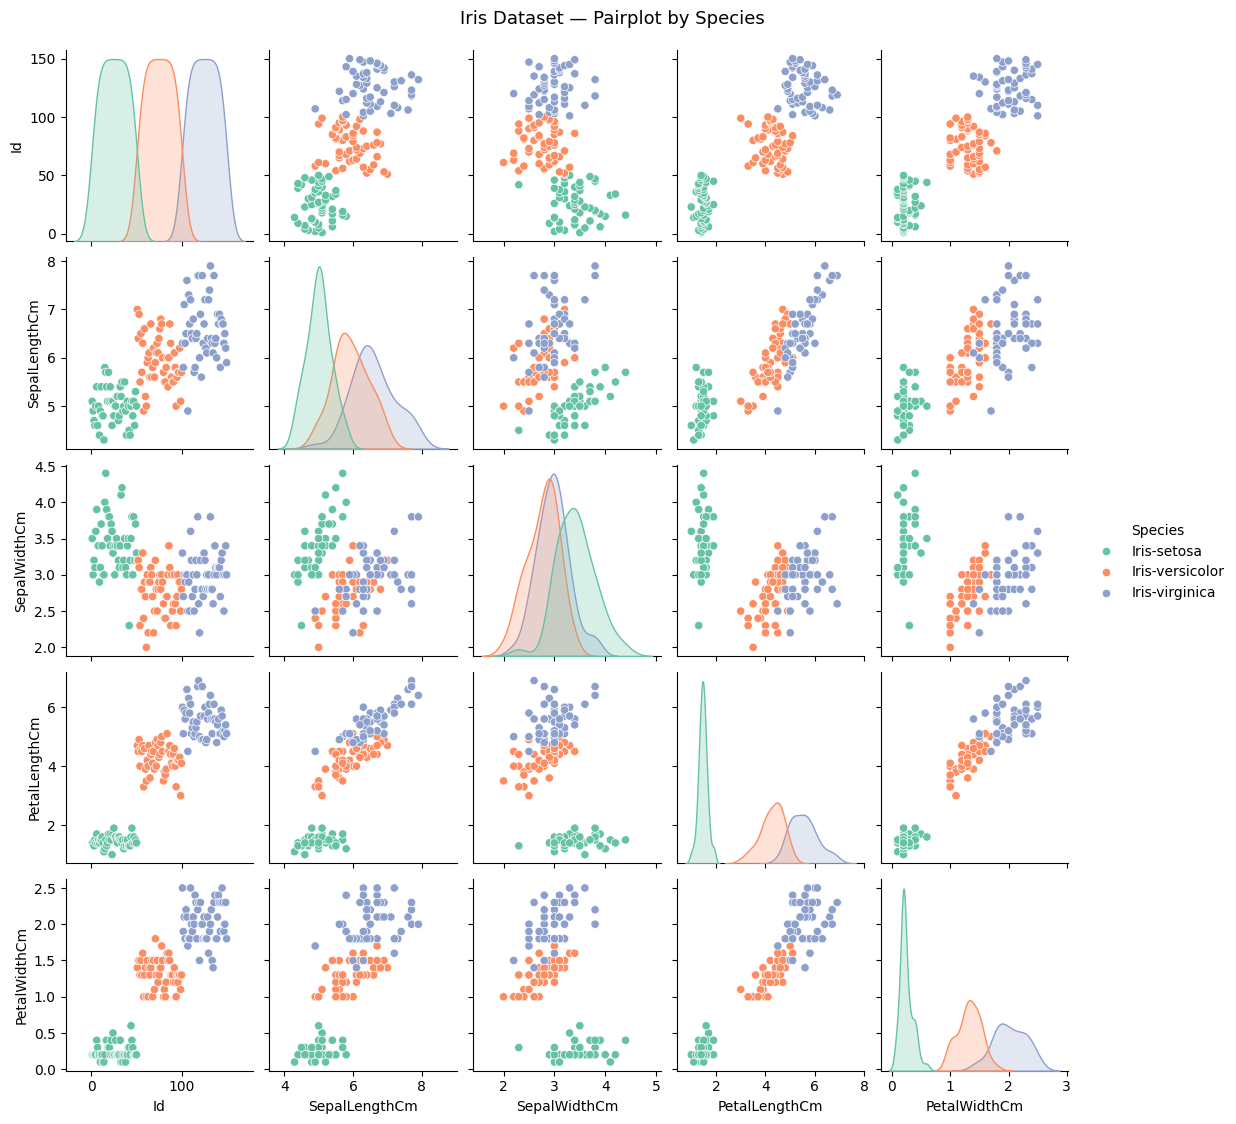


Finding:
  Petal length and petal width show the clearest separation between species.
  Iris setosa is clearly distinct. Virginica and Versicolor overlap slightly.
  This tells us petal measurements are the most useful features for classification.



In [10]:
# ── Visualization 2: Seaborn pairplot across all quantitative columns ────────
print('Generating pairplot (may take a moment)...')
sns.pairplot(iris_df, hue=species_col, palette='Set2', height=2.2)
plt.suptitle('Iris Dataset — Pairplot by Species', y=1.02, fontsize=13)
plt.show()

print('''
Finding:
  Petal length and petal width show the clearest separation between species.
  Iris setosa is clearly distinct. Virginica and Versicolor overlap slightly.
  This tells us petal measurements are the most useful features for classification.
''')

/tmp/ipykernel_500/3342682118.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris_df, x=species_col, y=qcol,
/tmp/ipykernel_500/3342682118.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris_df, x=species_col, y=qcol,
/tmp/ipykernel_500/3342682118.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris_df, x=species_col, y=qcol,
/tmp/ipykernel_500/3342682118.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=

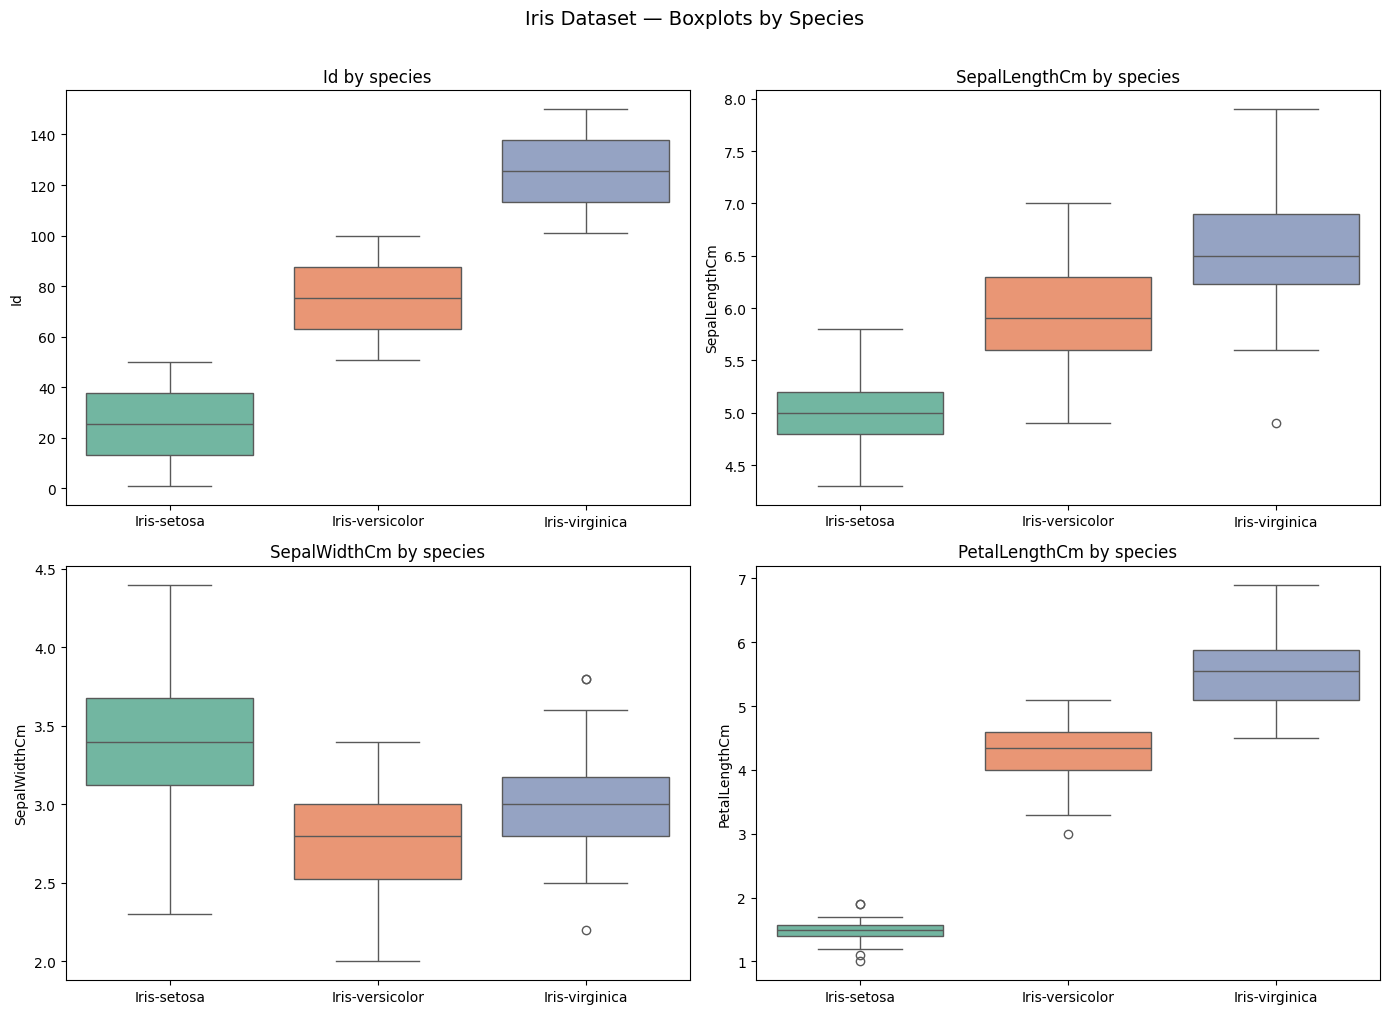

Finding: Boxplots confirm petal measurements have the least overlap between species.


In [11]:
# ── Visualization 3: Boxplot — spread of all numeric columns by species ──────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, qcol in enumerate(quant_cols[:4]):
    sns.boxplot(data=iris_df, x=species_col, y=qcol,
                palette='Set2', ax=axes[i])
    axes[i].set_title(f'{qcol} by species', fontsize=12)
    axes[i].set_xlabel('')

plt.suptitle('Iris Dataset — Boxplots by Species', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Finding: Boxplots confirm petal measurements have the least overlap between species.')

---
## Exercise 6 — Basic Observation Skills
**Objective:** Identify interesting columns in the Sleep dataset for further analysis.

In [12]:
# ── Reload sleep dataset and inspect columns ─────────────────────────────────
print('=== Sleep Dataset — Overview ===')
display(sleep_df.head())
print('\nColumns:')
print(sleep_df.columns.tolist())
print('\nMissing values:')
print(sleep_df.isnull().sum())
print('\nDescriptive stats:')
display(sleep_df.describe())

=== Sleep Dataset — Overview ===


,index,Year,Period,Avg hrs per day sleeping,Standard Error,Type of Days,Age Group,Activity,Sex
0,0,2003,Annual,8.57,0.018,All days,15 years and over,Sleeping,Both
1,1,2004,Annual,8.55,0.026,All days,15 years and over,Sleeping,Both
2,2,2005,Annual,8.62,0.023,All days,15 years and over,Sleeping,Both
3,3,2006,Annual,8.63,0.024,All days,15 years and over,Sleeping,Both
4,4,2007,Annual,8.57,0.024,All days,15 years and over,Sleeping,Both



Columns:
['index', 'Year', 'Period', 'Avg hrs per day sleeping', 'Standard Error', 'Type of Days', 'Age Group', 'Activity', 'Sex']

Missing values:
index                       0
Year                        0
Period                      0
Avg hrs per day sleeping    0
Standard Error              0
Type of Days                0
Age Group                   0
Activity                    0
Sex                         0
dtype: int64

Descriptive stats:


,index,Year,Avg hrs per day sleeping,Standard Error
count,945.000000,945.000000,945.000000,945.000000
mean,472.000000,2010.000000,8.806868,0.086958
std,272.942302,4.322782,0.545001,0.034631
min,0.000000,2003.000000,7.720000,0.018000
25%,236.000000,2006.000000,8.360000,0.063000
50%,472.000000,2010.000000,8.810000,0.084000
75%,708.000000,2014.000000,9.190000,0.106000
max,944.000000,2017.000000,10.650000,0.228000


Numeric columns  : ['index', 'Year', 'Avg hrs per day sleeping', 'Standard Error']
Categorical columns: ['Period', 'Type of Days', 'Age Group', 'Activity', 'Sex']


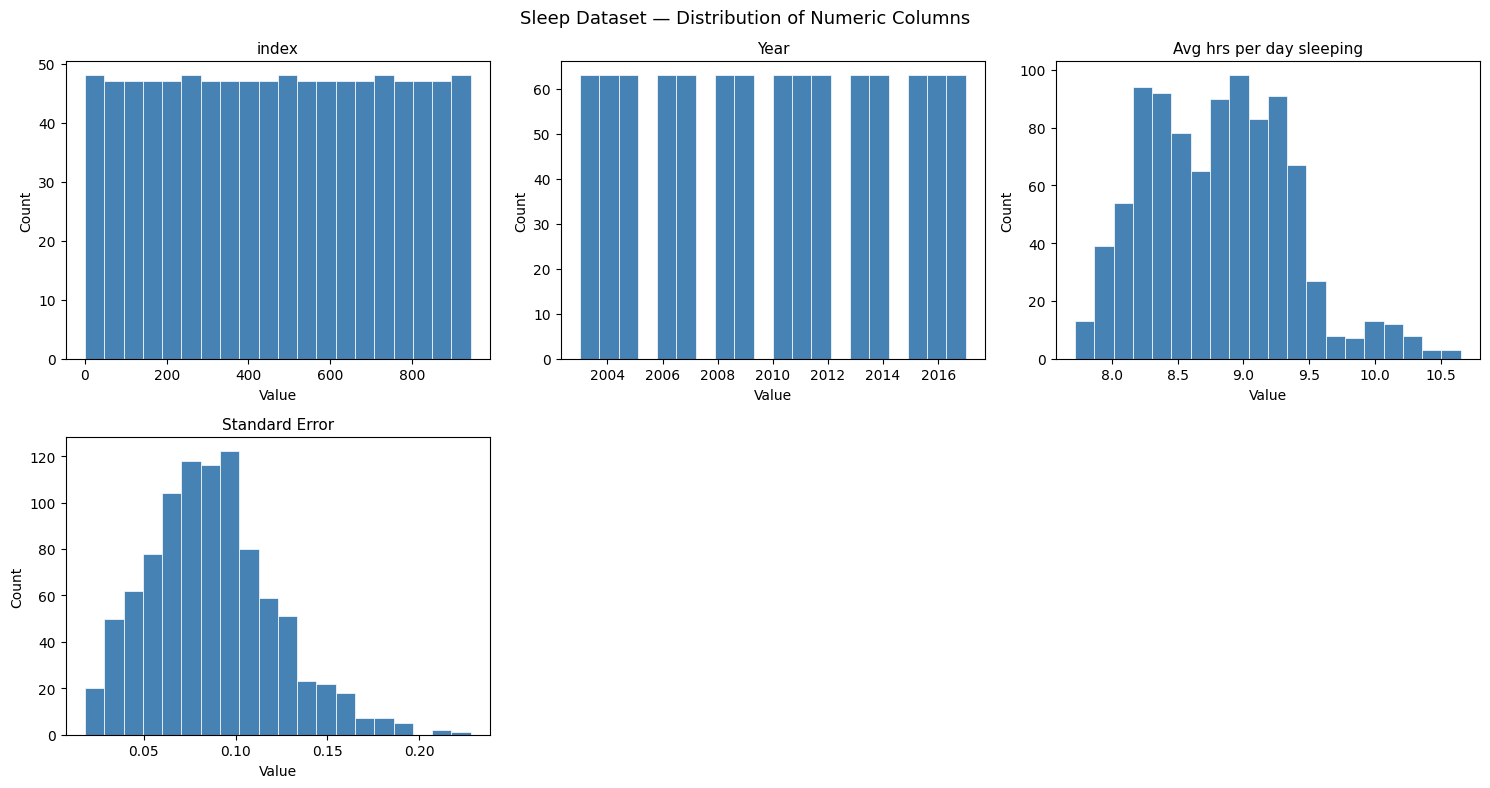

In [13]:
# ── Identify and visualize the most interesting columns ──────────────────────
num_cols = sleep_df.select_dtypes(include='number').columns.tolist()
cat_cols = sleep_df.select_dtypes(include='object').columns.tolist()

print('Numeric columns  :', num_cols)
print('Categorical columns:', cat_cols)

# Plot distribution of all numeric columns
if num_cols:
    n = len(num_cols)
    cols_per_row = 3
    rows = (n + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 4 * rows))
    axes = np.array(axes).flatten()

    for i, c in enumerate(num_cols):
        axes[i].hist(sleep_df[c].dropna(), bins=20,
                     color='steelblue', edgecolor='white', linewidth=0.5)
        axes[i].set_title(c, fontsize=11)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Count')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Sleep Dataset — Distribution of Numeric Columns', fontsize=13)
    plt.tight_layout()
    plt.show()

### Observation Report — Sleep Dataset

After inspecting the Sleep dataset, the following columns stand out as most interesting for analysis:

**For Trend Analysis:**
Any column representing time (year, date) combined with average sleep duration would be ideal for a **trend analysis** — we could answer: *Are Americans sleeping less over time?*

**For Group Comparison:**
Categorical columns like age group, gender, or employment status combined with sleep hours are perfect for **group comparison** — we could answer: *Do employed people sleep less than unemployed people?* or *Which age group sleeps the most?*

**Most Interesting Combination:**
The most valuable analysis would be comparing sleep duration across demographic groups over time — this would reveal both trends and inequalities in sleep patterns across the American population.

**Key Observation:**
Columns with high variance (large standard deviation relative to the mean) are the most interesting for analysis because they suggest meaningful differences between groups rather than uniform behavior.